In [10]:
import os, json
import pandas as pd
import matplotlib.pyplot as plt

from util.static import PATH_OUTPUT, PATH_LABELING, PATH_FIGURES_DISTRIBUTIONS

# Data Visualization

This notebook contains the code to visualize the distribution of the labeled data (both the automatic and manual) on file (i.e., subflow) level.

In [2]:
# read the merged data by loading the file rq4tlr-merged.csv from the output folder
df = pd.read_csv(os.path.join(PATH_OUTPUT, 'rq4tlr-merged.csv'))

To prepare the visualization, load the [variables.json](./../data/output/variables.json) file containing information about the label, name, and type of all variables.

In [11]:
# load the variables.json file from the output folder
variables_filename: str = os.path.join(PATH_OUTPUT, 'variables.json')
with open(variables_filename, 'r', encoding='utf-8') as f:
    variables = json.load(f)

In [ ]:
# determine all available types of variables
vartypes: list = list(set([variable['type'] for variable in variables]))

In [ ]:
# create an association of variable types and their corresponding variables
vars_by_type: dict = {vartype: [variable['label'] for variable in variables if variable['type'] == vartype] for vartype in vartypes}

## Visualization

The core of this notebook is the visualization of the prepared data.
To this end, the distribution of every variable contained in the `variables` dictionary will be visualized in an appropriate figure.
All figures are shown in the notebook and also saved in PDF format in the `PATH_FIGURES_DISTRIBUTIONS` file path.

In [17]:
# define the axis names per variable name
axis_names: dict[str, str] = {variable['label']: variable['name'] for variable in variables}

### Count Variables

Count variables are variables with values in $\mathbb{N}$, i.e., positive (or zero) integers.
The following code block visualizes the distribution of count variables in box plots.

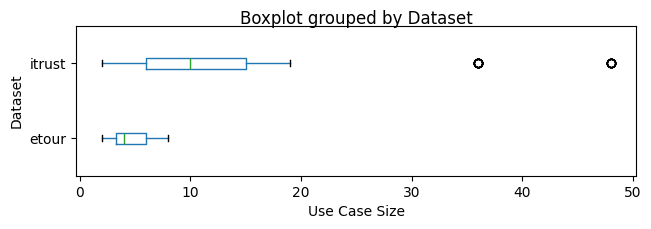

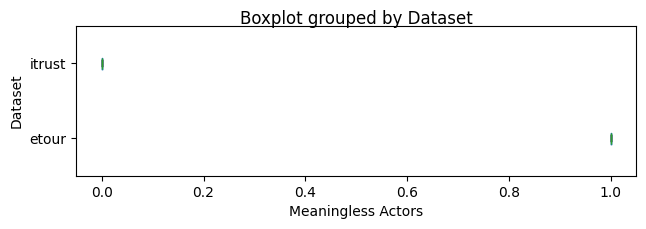

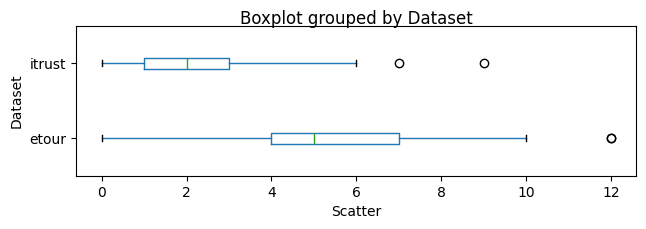

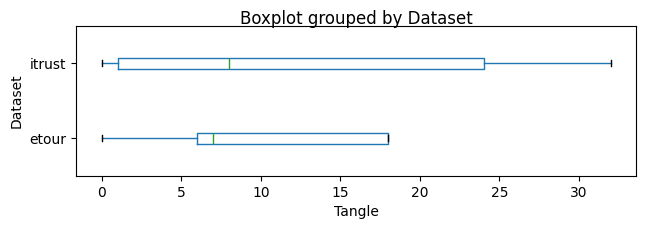

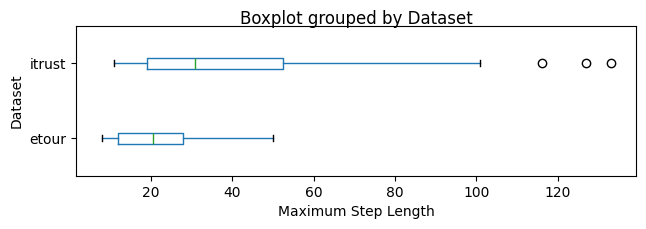

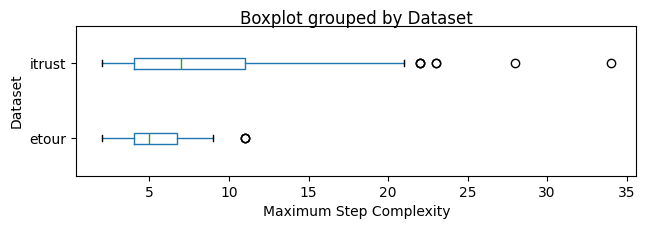

In [18]:
# Generate a horizontal box plot for each variable in the "count" category
for variable in vars_by_type["count"]:
    # create a horizontal box plot visualizing the distribution of the variable, one for each value of the Dataset column
    df.boxplot(column = variable, by = "Dataset", vert = False, showfliers = True, figsize=(7,2))

    plt.title("") # remove the title
    plt.xlabel(axis_names[variable]) # set the x-axis label
    plt.grid(False) # remove all vertical and horizontal lines

    # Save the plot in PDF format
    plt.savefig(os.path.join(PATH_FIGURES_DISTRIBUTIONS, f'{variable}.pdf'), bbox_inches='tight')
    plt.show()

### Boolean Variables

Boolean variables are categorical variables with either `True` or `False` as values.
The following code block visualizes all ratios of distributions.

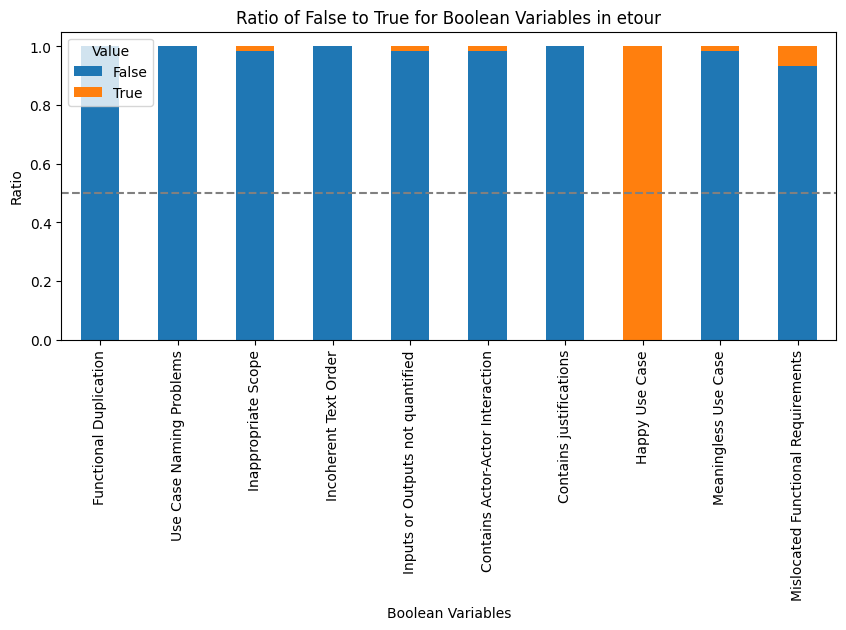

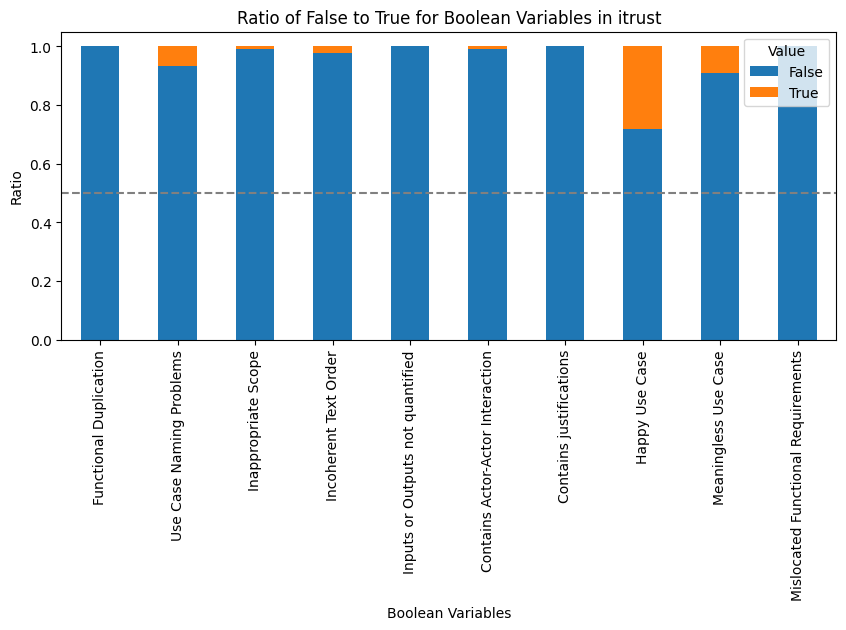

In [19]:
# Iterate over each unique value in the Dataset column
for dataset in df['Dataset'].unique():
    # Filter the dataframe for the current dataset
    df_filtered = df[df['Dataset'] == dataset]
    
    # Calculate the ratio of True to False for each boolean variable
    boolean_ratios = df_filtered[vars_by_type["boolean"]].apply(lambda x: x.value_counts(normalize=True)).T
    boolean_ratios.columns = ['False', 'True']
    
    # Plot the stacked bar chart
    boolean_ratios.plot(kind='bar', stacked=True, figsize=(10, 4))
    
    # Set the title and labels
    plt.title(f'Ratio of False to True for Boolean Variables in {dataset}')
    plt.xlabel('Boolean Variables')
    plt.ylabel('Ratio')
    plt.xticks(rotation=90)
    plt.legend(title='Value')
    plt.axhline(y=0.5, color='grey', linestyle='--')
    plt.xticks(range(len(boolean_ratios.index)), [axis_names[name] for name in boolean_ratios.index])
    
    # Save the plot in PDF format
    plt.savefig(os.path.join(PATH_FIGURES_DISTRIBUTIONS, f'boolean_ratios_{dataset}.pdf'), bbox_inches='tight')
    
    # Show the plot
    plt.show()

### Ratio Variables

Ratio variables are real values bounded in $[0, 1]$.


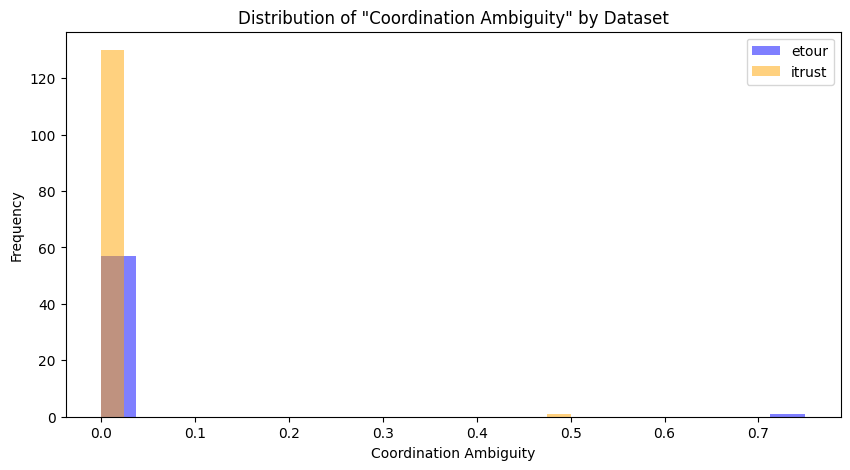

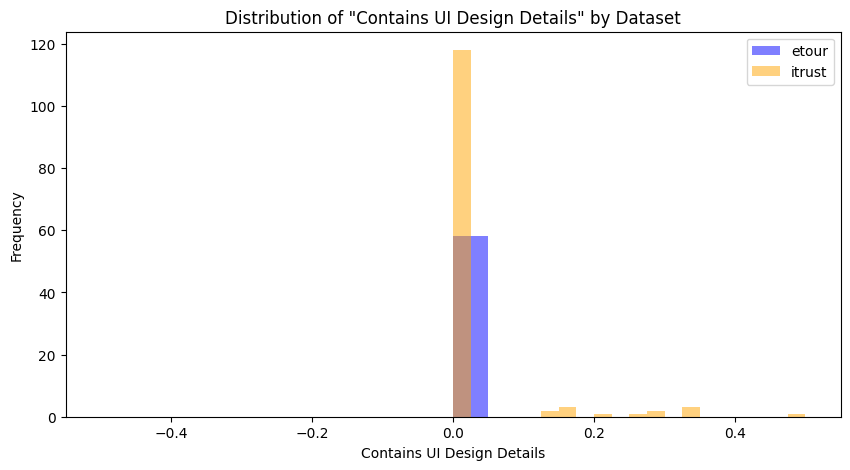

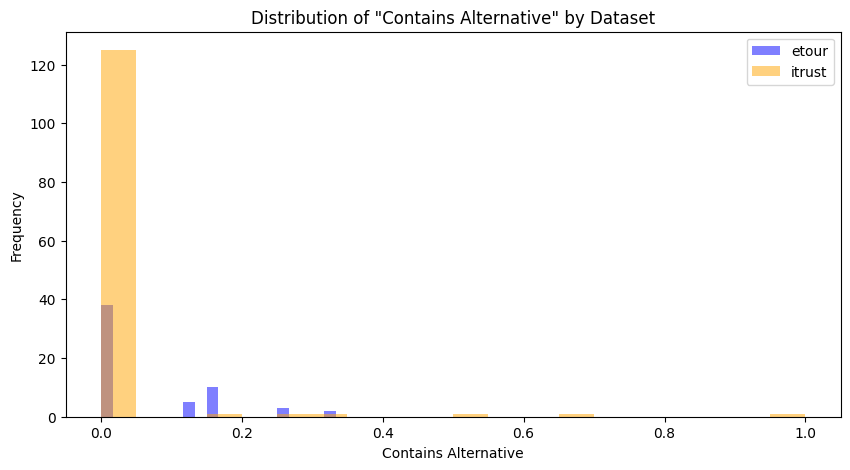

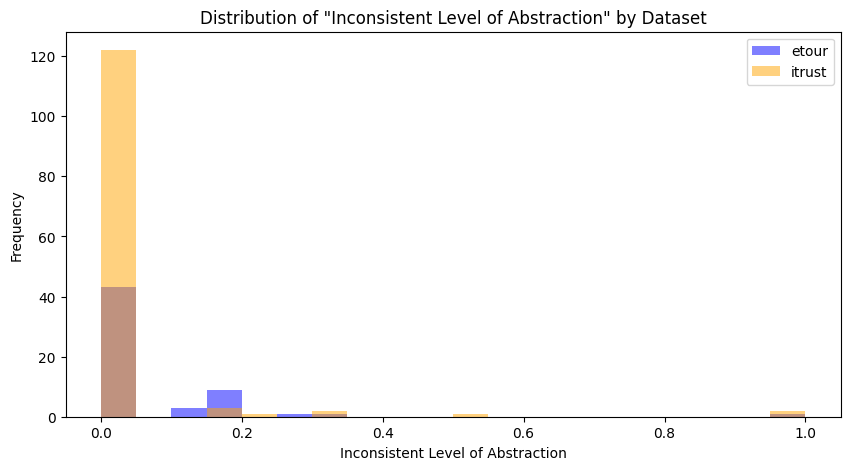

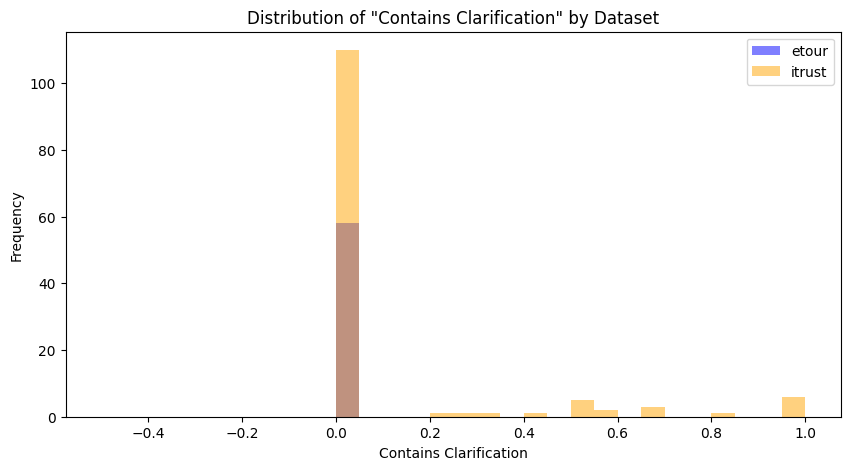

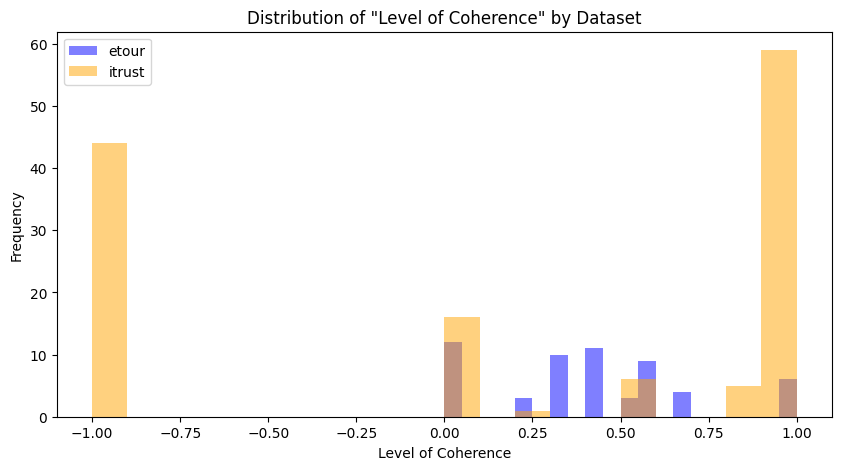

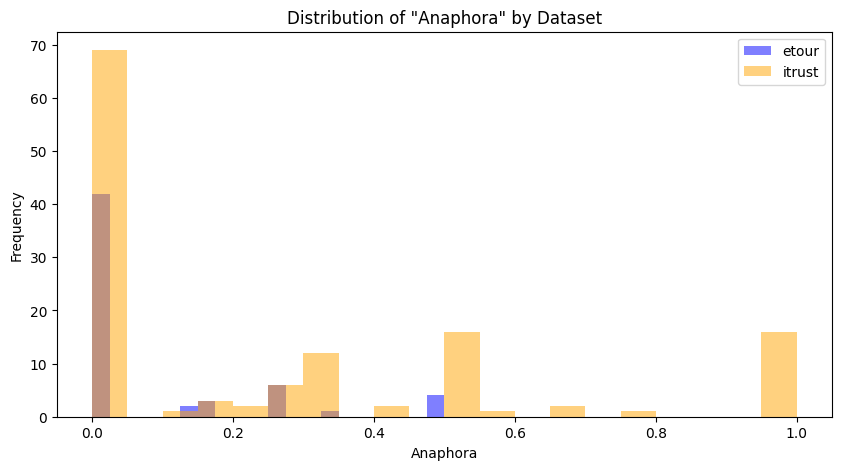

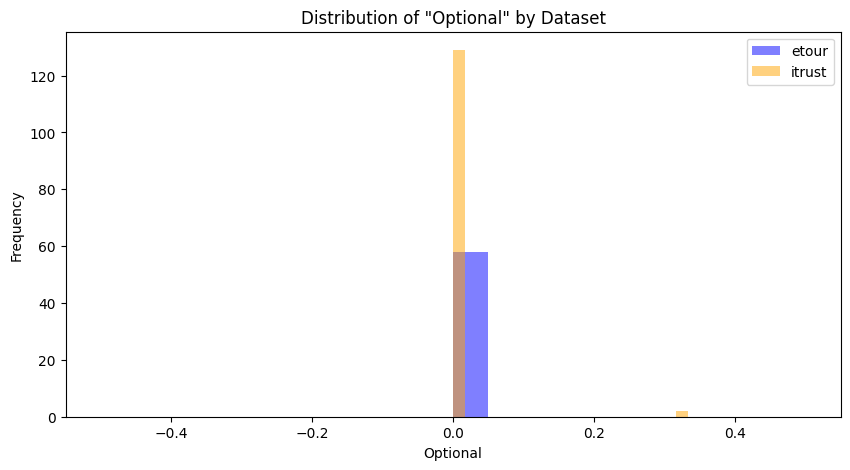

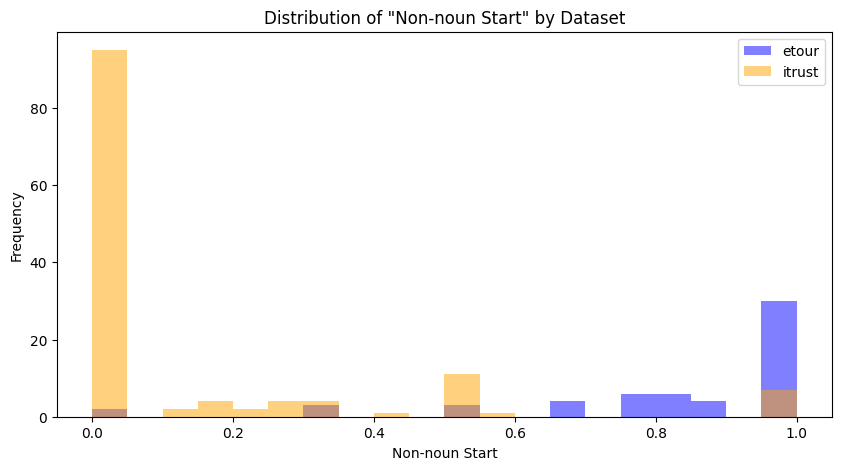

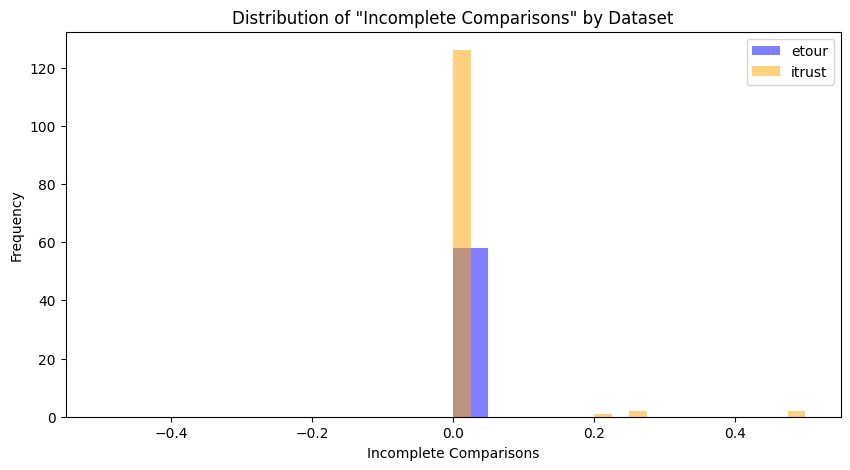

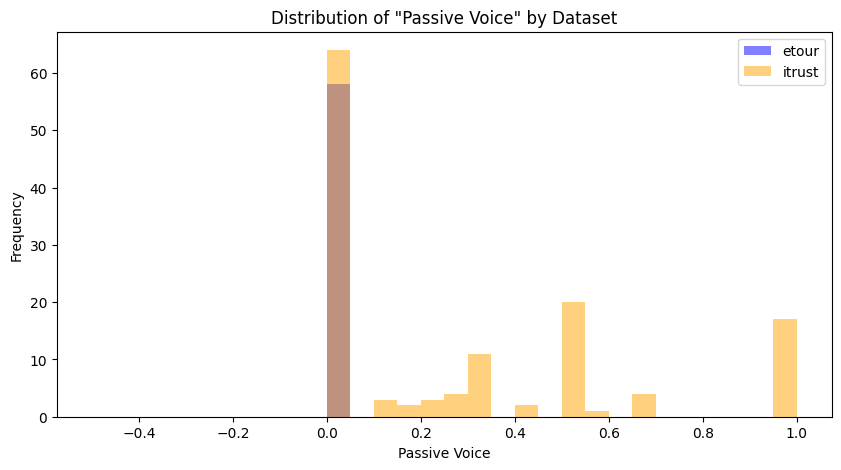

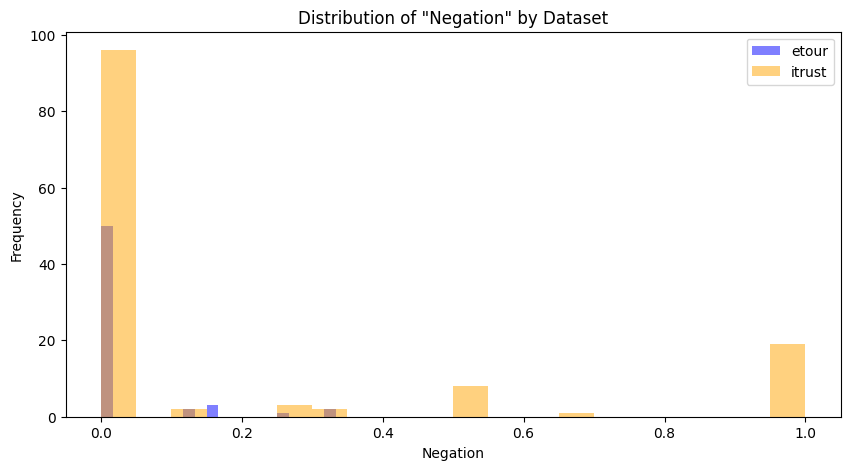

In [21]:
# Generate a histogram for each variable in the "ratio" category
for variable in vars_by_type["ratio"]:
    # Plot the histogram of the variable, one for each value of the Dataset column, with different colors in one figure
    df[df['Dataset'] == 'etour'][variable].plot(kind='hist', bins=20, alpha=0.5, color='blue', label='etour', figsize=(10, 5))
    df[df['Dataset'] == 'itrust'][variable].plot(kind='hist', bins=20, alpha=0.5, color='orange', label='itrust')

    # Set the title and labels
    plt.title(f'Distribution of "{axis_names[variable]}" by Dataset')
    plt.xlabel(axis_names[variable])
    plt.ylabel('Frequency')
    plt.legend()

    # Save the plot in PDF format and show the plot
    plt.savefig(os.path.join(PATH_FIGURES_DISTRIBUTIONS, f'{variable}_histogram.pdf'), bbox_inches='tight')
    plt.show()